# **Import thư viện**

In [ ]:
!pip install powerlaw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 2.8 MB/s eta 0:00:00


In [ ]:
import gzip
import networkx as nx
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# **Load data**

In [ ]:
class LoadData:
    def __init__(self, file_path):
        self.file_path = file_path
        self.graph = nx.DiGraph()

    def load(self):
        with open(self.file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.startswith('#'):
                    continue

                parts = line.split()
                if len(parts) == 2:
                    u, v = map(int, parts)
                    self.graph.add_edge(u, v)

        return self.graph

In [ ]:
loader = LoadData("/content/drive/MyDrive/Social Network Analysis/Data/Amazon0302.txt")
G = loader.load()

# **Basic statistic**

In [ ]:
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 262111
Edges: 1234877


Sparse Graph

In [ ]:
n = G.number_of_nodes()
m = G.number_of_edges()

density = m / (n * (n - 1))

density

1.7974419114806206e-05

# **Degree Analysis**

## **Basic statistic**

In [ ]:
degrees = [d for _, d in G.degree()]
in_degrees = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

degree_stats = pd.concat([
    pd.Series(degrees, name='degree').describe(),
    pd.Series(in_degrees, name='in_degree').describe(),
    pd.Series(out_degrees, name='out_degree').describe()
], axis=1)

degree_stats

,degree,in_degree,out_degree
count,262111.000000,262111.000000,262111.000000
mean,9.422550,4.711275,4.711275
std,5.919202,5.707922,0.951540
min,1.000000,1.000000,0.000000
25%,7.000000,2.000000,5.000000
50%,8.000000,3.000000,5.000000
75%,11.000000,6.000000,5.000000
max,425.000000,420.000000,5.000000


## **Degree distribution**

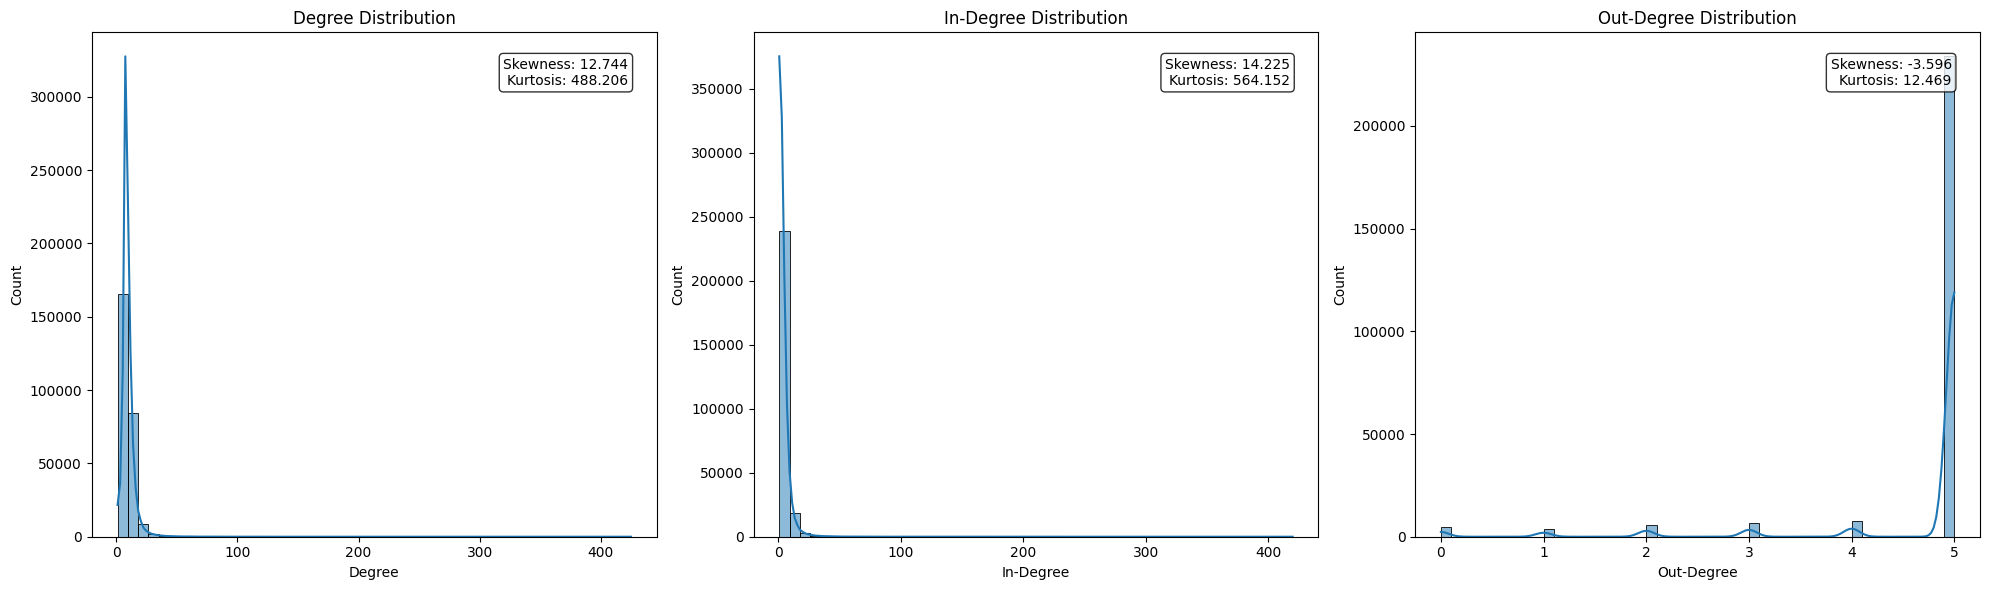

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Degree Distribution
sns.histplot(degrees, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Degree Distribution")
axes[0].set_xlabel("Degree")
skew_d = skew(degrees)
kurt_d = kurtosis(degrees)
axes[0].text(0.95, 0.95, f'Skewness: {skew_d:.3f}\nKurtosis: {kurt_d:.3f}',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# In-Degree Distribution
sns.histplot(in_degrees, bins=50, kde=True, ax=axes[1])
axes[1].set_title("In-Degree Distribution")
axes[1].set_xlabel("In-Degree")
skew_in = skew(in_degrees)
kurt_in = kurtosis(in_degrees)
axes[1].text(0.95, 0.95, f'Skewness: {skew_in:.3f}\nKurtosis: {kurt_in:.3f}',
             transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Out-Degree Distribution
sns.histplot(out_degrees, bins=50, kde=True, ax=axes[2])
axes[2].set_title("Out-Degree Distribution")
axes[2].set_xlabel("Out-Degree")
skew_out = skew(out_degrees)
kurt_out = kurtosis(out_degrees)
axes[2].text(0.95, 0.95, f'Skewness: {skew_out:.3f}\nKurtosis: {kurt_out:.3f}',
             transform=axes[2].transAxes, ha='right', va='top',
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

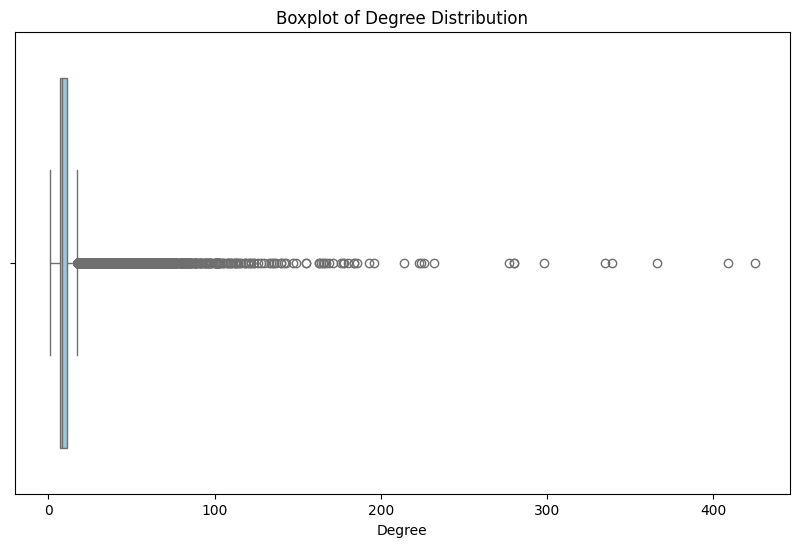

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=degrees, color='skyblue')
plt.title("Boxplot of Degree Distribution")
plt.xlabel("Degree")
plt.show()

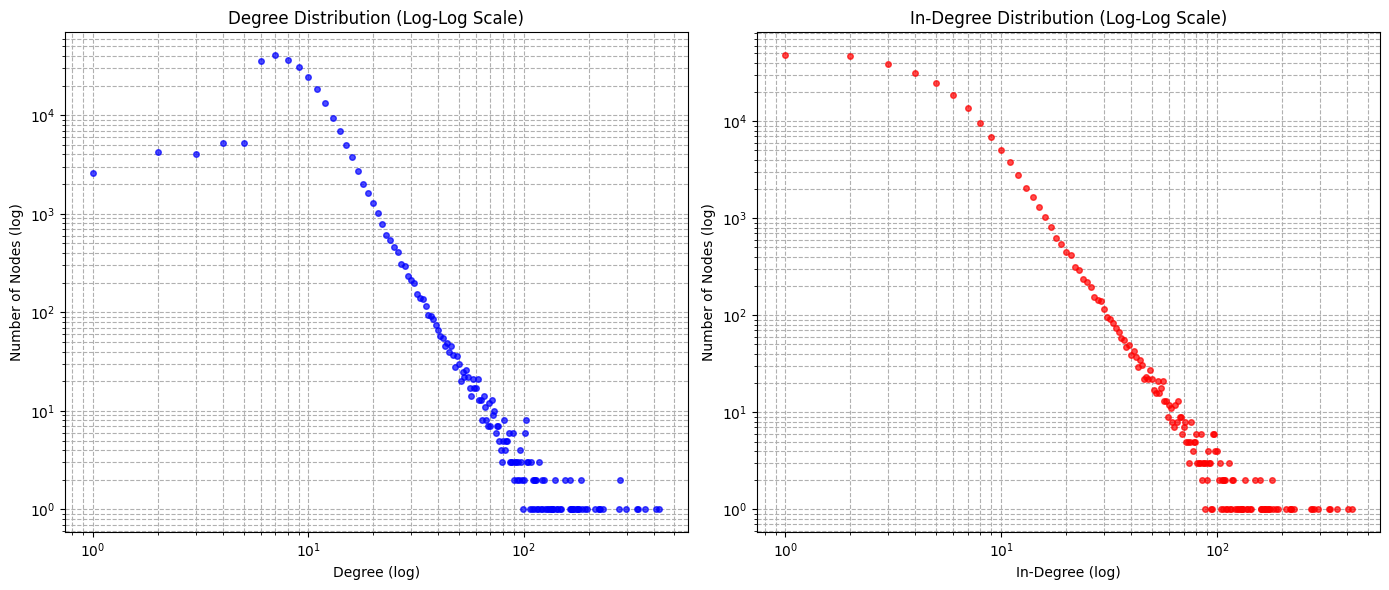

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Tính tần suất Degree
degree_values, degree_counts = np.unique(degrees, return_counts=True)

# Tính tần suất In-Degree
in_values, in_counts = np.unique(in_degrees, return_counts=True)

# Tạo 2 subplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Degree Distribution
axes[0].loglog(degree_values, degree_counts, 'bo', markersize=4, alpha=0.7)
axes[0].set_title("Degree Distribution (Log-Log Scale)")
axes[0].set_xlabel("Degree (log)")
axes[0].set_ylabel("Number of Nodes (log)")
axes[0].grid(True, which="both", ls="--")

# In-Degree Distribution
axes[1].loglog(in_values, in_counts, 'ro', markersize=4, alpha=0.7)
axes[1].set_title("In-Degree Distribution (Log-Log Scale)")
axes[1].set_xlabel("In-Degree (log)")
axes[1].set_ylabel("Number of Nodes (log)")
axes[1].grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import powerlaw

results = []

for name, data in [
    ("Degree", degrees),
    ("In-Degree", in_degrees)
]:
    # Tự động tìm xmin
    fit = powerlaw.Fit(data, discrete=True)

    R_exp, p_exp = fit.distribution_compare(
        'power_law',
        'exponential'
    )

    R_log, p_log = fit.distribution_compare(
        'power_law',
        'lognormal'
    )

    results.append({
        "Distribution": name,
        "Alpha": fit.power_law.alpha,
        "xmin": fit.xmin,
        "R (PowerLaw vs Exp)": R_exp,
        "p (PowerLaw vs Exp)": p_exp,
        "R (PowerLaw vs Lognormal)": R_log,
        "p (PowerLaw vs Lognormal)": p_log
    })

powerlaw_df = pd.DataFrame(results)
powerlaw_df.round(4)

Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 159/159 [00:07<00:00, 21.22it/s]
/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 155/155 [00:03<00:00, 48.93it/s] 
/usr/local/lib/python3.12/dist-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


,Distribution,Alpha,xmin,R (PowerLaw vs Exp),p (PowerLaw vs Exp),R (PowerLaw vs Lognormal),p (PowerLaw vs Lognormal)
0,Degree,2.9607,6.0,-14086.2024,0.0,-19458.447,0.0
1,In-Degree,2.9151,5.0,5226.5670,0.0,-1306.074,0.0


Kết luận: mạng của bạn có heavy-tailed distribution và hub nodes, nhưng bằng chứng hiện tại ủng hộ lognormal

# **Connected Components**

In [ ]:
# 1. Weakly Connected Components (WCC)
wcc = list(nx.weakly_connected_components(G))
num_wcc = len(wcc)
lcc_wcc = max(wcc, key=len)

# 2. Strongly Connected Components (SCC)
scc = list(nx.strongly_connected_components(G))
num_scc = len(scc)
lcc_scc = max(scc, key=len)

# Print results
print(f"--- Weakly Connected Components ---")
print(f"Number of WCCs: {num_wcc}")
print(f"Size of Largest WCC (LCC): {len(lcc_wcc)} nodes")
print(f"Coverage of LCC: {(len(lcc_wcc)/G.number_of_nodes())*100:.2f}%")

print(f"\n--- Strongly Connected Components ---")
print(f"Number of SCCs: {num_scc}")
print(f"Size of Largest SCC: {len(lcc_scc)} nodes")
print(f"Coverage of Largest SCC: {(len(lcc_scc)/G.number_of_nodes())*100:.2f}%")

--- Weakly Connected Components ---
Number of WCCs: 1
Size of Largest WCC (LCC): 262111 nodes
Coverage of LCC: 100.00%

--- Strongly Connected Components ---
Number of SCCs: 6594
Size of Largest SCC: 241761 nodes
Coverage of Largest SCC: 92.24%


# **Hub detection**

In [ ]:
hubs, authorities = nx.hits(G)

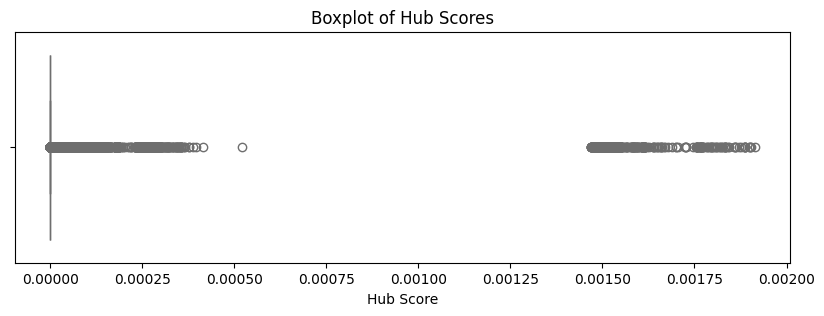

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert hub scores to a list
hub_values = list(hubs.values())

plt.figure(figsize=(10, 3))

sns.boxplot(
    x=hub_values,
    color='lightcoral'
)

plt.title("Boxplot of Hub Scores")
plt.xlabel("Hub Score")

plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Lấy danh sách các giá trị hub
hub_values = np.array(list(hubs.values()))

# 1. Tính các tứ phân vị
q1 = np.percentile(hub_values, 25)
median = np.median(hub_values)
q3 = np.percentile(hub_values, 75)

# 2. Tính IQR (Khoảng biến thiên tứ phân vị)
iqr = q3 - q1

# 3. Tính các ngưỡng (Limits) để xác định điểm ngoại lệ (Outliers)
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# 4. Tìm giá trị Min và Max thực tế (không tính outliers)
# Lưu ý: min_val và max_val của râu (whiskers)
min_val = np.min(hub_values[hub_values >= lower_limit])
max_val = np.max(hub_values[hub_values <= upper_limit])

# 5. Đếm số lượng điểm ngoại lệ (Outliers)
outliers = hub_values[(hub_values < lower_limit) | (hub_values > upper_limit)]

# Hiển thị kết quả dưới dạng bảng
boxplot_stats = {
    "Chỉ số": ["Minimum (Whiskers)", "Q1 (25th Percentile)", "Median", "Q3 (75th Percentile)", "Maximum (Whiskers)", "IQR", "Lower Limit", "Upper Limit", "Số lượng Outliers"],
    "Giá trị": [min_val, q1, median, q3, max_val, iqr, lower_limit, upper_limit, len(outliers)]
}

df_stats = pd.DataFrame(boxplot_stats)
df_stats

,Chỉ số,Giá trị
0,Minimum (Whiskers),-6.760403e-21
1,Q1 (25th Percentile),1.351064e-10
2,Median,2.221985e-09
3,Q3 (75th Percentile),4.430907e-08
4,Maximum (Whiskers),1.105608e-07
5,IQR,4.417396e-08
6,Lower Limit,-6.612583e-08
7,Upper Limit,1.105700e-07
8,Số lượng Outliers,4.411600e+04


In [ ]:
# Lọc các node và hub score là outlier
outlier_hubs = {node: score for node, score in hubs.items() if score < lower_limit or score > upper_limit}

# Tạo DataFrame hub
hub = pd.DataFrame(list(outlier_hubs.items()), columns=['Node', 'HubScore'])

# Hiển thị 5 dòng đầu tiên của DataFrame hub
hub

,Node,HubScore
0,0,2.786885e-07
1,1,3.369400e-07
2,2,2.789817e-07
3,3,2.723491e-07
4,4,2.764088e-06
...,...,...
44111,262066,1.472360e-07
44112,262055,2.347738e-07
44113,262088,3.887745e-06
44114,262077,1.788399e-06


In [ ]:
# Thiết lập ngưỡng threshold
threshold = 0.00125

# Lọc các superhub
superhubs = {node: score for node, score in hubs.items() if score >= threshold}

# Tạo DataFrame superhub
df_superhub = pd.DataFrame(list(superhubs.items()), columns=['Node', 'HubScore'])

# Sắp xếp theo HubScore giảm dần
df_superhub = df_superhub.sort_values(by='HubScore', ascending=False)

# Hiển thị kết quả
print(f"Số lượng superhub tìm thấy: {len(df_superhub)}")
df_superhub

Số lượng superhub tìm thấy: 420


,Node,HubScore
246,185364,0.001913
196,179956,0.001904
72,126766,0.001902
392,244671,0.001901
11,40352,0.001898
...,...,...
92,75189,0.001469
98,98203,0.001469
170,139943,0.001469
33,42199,0.001469


In [ ]:
# Tạo tập hợp các Node ID của superhub để loại trừ
superhub_nodes = set(df_superhub['Node'])

# Lọc real_hub: những node trong df 'hub' (outliers) mà không nằm trong 'df_superhub'
real_hub = hub[~hub['Node'].isin(superhub_nodes)].copy()

# Sắp xếp theo HubScore giảm dần
real_hub = real_hub.sort_values(by='HubScore', ascending=False)

In [ ]:
real_hub

,Node,HubScore
3378,14949,5.212095e-04
42937,252242,4.155842e-04
5308,33805,3.965450e-04
26155,120032,3.873301e-04
2006,6432,3.777552e-04
...,...,...
23913,119685,1.105894e-07
37210,202043,1.105892e-07
25482,128111,1.105837e-07
21980,111046,1.105745e-07


In [ ]:
# 1. Tạo subgraph chỉ chứa các superhub
superhub_subgraph = G.subgraph(superhub_nodes)

# 2. Tìm các Strongly Connected Components (SCC) trong subgraph superhub
superhub_scc = list(nx.strongly_connected_components(superhub_subgraph))
num_superhub_scc = len(superhub_scc)
lcc_superhub_scc = max(superhub_scc, key=len)

# 3. In kết quả
print(f"--- Strongly Connected Components of Superhubs ---")
print(f"Số lượng Superhub: {len(superhub_nodes)}")
print(f"Số lượng SCC trong nhóm Superhub: {num_superhub_scc}")
print(f"Kích thước SCC lớn nhất: {len(lcc_superhub_scc)} nodes")
print(f"Tỷ lệ bao phủ của SCC lớn nhất trong nhóm Superhub: {(len(lcc_superhub_scc)/len(superhub_nodes))*100:.2f}%")

--- Strongly Connected Components of Superhubs ---
Số lượng Superhub: 420
Số lượng SCC trong nhóm Superhub: 301
Kích thước SCC lớn nhất: 16 nodes
Tỷ lệ bao phủ của SCC lớn nhất trong nhóm Superhub: 3.81%


In [ ]:
# 1. Tìm các Weakly Connected Components (WCC) trong subgraph superhub
superhub_wcc = list(nx.weakly_connected_components(superhub_subgraph))
num_superhub_wcc = len(superhub_wcc)
lcc_superhub_wcc = max(superhub_wcc, key=len)

# 2. In kết quả
print(f"--- Weakly Connected Components of Superhubs ---")
print(f"Số lượng Superhub: {len(superhub_nodes)}")
print(f"Số lượng WCC trong nhóm Superhub: {num_superhub_wcc}")
print(f"Kích thước WCC lớn nhất: {len(lcc_superhub_wcc)} nodes")
print(f"Tỷ lệ bao phủ của WCC lớn nhất trong nhóm Superhub: {(len(lcc_superhub_wcc)/len(superhub_nodes))*100:.2f}%")

--- Weakly Connected Components of Superhubs ---
Số lượng Superhub: 420
Số lượng WCC trong nhóm Superhub: 129
Kích thước WCC lớn nhất: 271 nodes
Tỷ lệ bao phủ của WCC lớn nhất trong nhóm Superhub: 64.52%


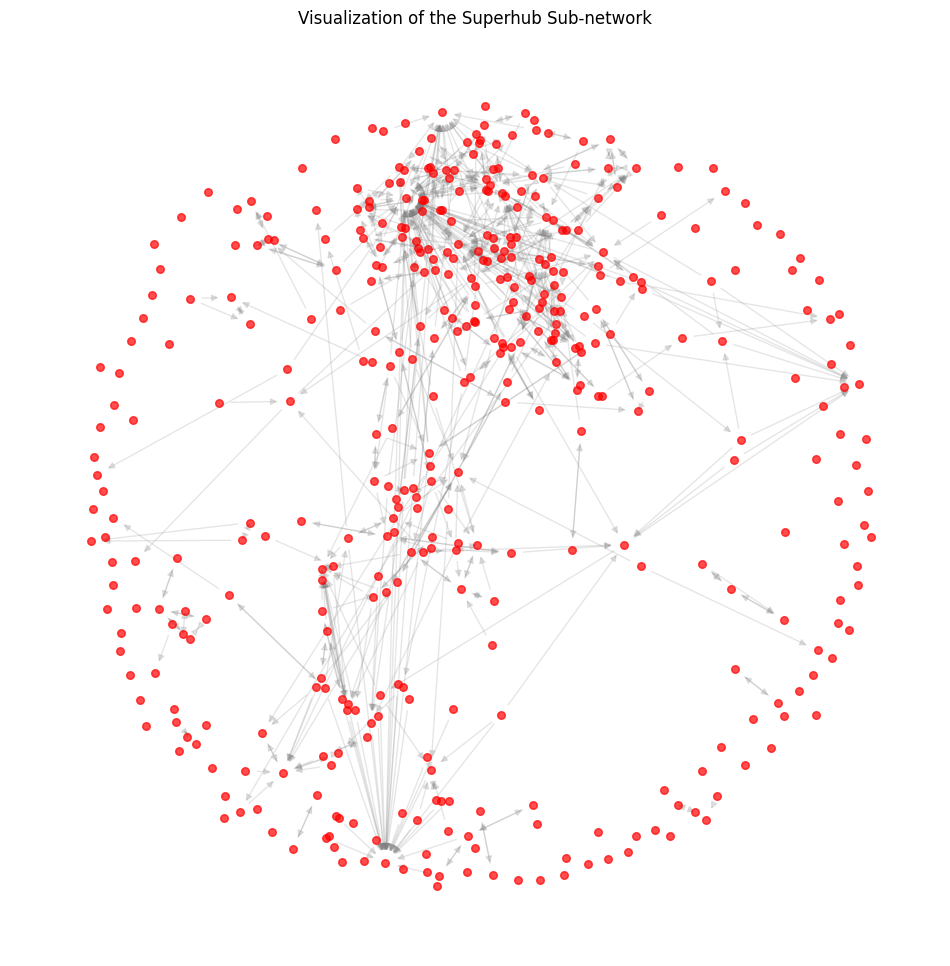

In [ ]:
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(superhub_subgraph, k=0.15, seed=42)

# Vẽ các node
nx.draw_networkx_nodes(superhub_subgraph, pos,
                       node_size=30,
                       node_color='red',
                       alpha=0.7)

# Vẽ các cạnh
nx.draw_networkx_edges(superhub_subgraph, pos,
                       alpha=0.2,
                       edge_color='gray',
                       arrows=True,
                       arrowsize=10)

plt.title("Visualization of the Superhub Sub-network")
plt.axis('off')
plt.show()

### **PageRank**

## **Centrality analysis**

In [ ]:
pagerank = nx.pagerank(G)

In [ ]:
sorted(
    pagerank.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

[(4429, 0.0004908233235561096),
 (33, 0.00046603120282987106),
 (8, 0.00037459904050519364),
 (93, 0.0003385011976870984),
 (481, 0.00033685536657304384),
 (151, 0.00031048807778399917),
 (9106, 0.0003099181437374966),
 (2501, 0.00030673714076483324),
 (14949, 0.0003003492021384393),
 (1241, 0.00027961265392434387),
 (5737, 0.00027455108827477973),
 (2353, 0.00025829588732875466),
 (10519, 0.00023290168586415248),
 (12771, 0.00022826240736709743),
 (18, 0.00021619270540095052),
 (94, 0.0001996754403762948),
 (95, 0.00019598326843428567),
 (13304, 0.0001907909619989973),
 (56, 0.0001902730043706267),
 (5765, 0.0001889453978119494)]

In [ ]:
import pandas as pd

# Get top 10 nodes by PageRank
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:20]

# Create list of dictionaries including degree
ranking_data = []
for node, pr_score in top_pagerank:
    ranking_data.append({
        "Node": node,
        "PageRank": pr_score,
        "Degree": G.degree(node)
    })

# Display as DataFrame
df_top_pagerank = pd.DataFrame(ranking_data)
df_top_pagerank

,Node,PageRank,Degree
0,4429,0.000491,409
1,33,0.000466,366
2,8,0.000375,298
3,93,0.000339,224
4,481,0.000337,280
5,151,0.000310,90
6,9106,0.000310,232
7,2501,0.000307,196
8,14949,0.000300,425
9,1241,0.000280,223


### **Closeness**

In [ ]:
degree_sorted = sorted(
    G.degree(),
    key=lambda x: x[1],
    reverse=True
)

top_nodes = [n for n, d in degree_sorted[:500]]

closeness = {
    n: nx.closeness_centrality(G, u=n)
    for n in top_nodes
}

In [ ]:
sorted(
    closeness.items(),
    key=lambda x: x[1],
    reverse=True
)[:25]

[(33, 0.11489626538165047),
 (297, 0.11476793677042493),
 (93, 0.11430479344472086),
 (4429, 0.11388286258775564),
 (2501, 0.11382043404185241),
 (2353, 0.11210205724115017),
 (3589, 0.1101117009330964),
 (56, 0.10922557448739255),
 (151, 0.10902521291269927),
 (5120, 0.10868291105834994),
 (95, 0.10854726770904086),
 (5121, 0.10836154695298722),
 (94, 0.10800655044801952),
 (429, 0.10744684730613531),
 (449, 0.10505793370534307),
 (1241, 0.10501227002325336),
 (4931, 0.10425926917404603),
 (7303, 0.10146144252418127),
 (9106, 0.10065641215460981),
 (448, 0.1005753319752191),
 (8458, 0.09965403808621713),
 (447, 0.0995601157572505),
 (1964, 0.09880201604426532),
 (331, 0.09821127207406159),
 (518, 0.09778612027226935)]

### Nhận xét

Các node có Closeness Centrality cao nhất có giá trị dao động từ 0.0978 đến 0.1149, cho thấy chúng nằm ở vị trí trung tâm của mạng và có khả năng tiếp cận các node khác với số bước trung bình thấp. Chênh lệch giữa các giá trị Closeness không lớn, phản ánh rằng vai trò trung tâm được phân bổ cho nhiều node thay vì tập trung vào một node duy nhất. Điều này cho thấy mạng có cấu trúc tương đối phân tán và vẫn duy trì khả năng kết nối tốt thông qua nhiều node trung tâm. Các node này đóng vai trò quan trọng trong việc lan truyền thông tin nhanh chóng và nâng cao hiệu quả kết nối trong toàn mạng.

# Betweeness

In [ ]:
betweenness = nx.betweenness_centrality(
    G,
    k=500,
    seed=42
)

top_betweenness = sorted(
    betweenness.items(),
    key=lambda x: x[1],
    reverse=True
)[:25]

top_betweenness

[(7629, 0.022061728829840126),
 (13222, 0.018431285946482124),
 (6935, 0.01778557863524323),
 (2501, 0.016875449482099018),
 (3464, 0.016633244450602023),
 (10072, 0.014508141945900286),
 (12031, 0.013936214233042725),
 (4572, 0.013128700072364479),
 (7628, 0.012775822783374682),
 (7303, 0.012149629014151932),
 (13304, 0.01199974670553994),
 (97, 0.01172056796441022),
 (8458, 0.011617488663341679),
 (19527, 0.010941871086225154),
 (5765, 0.010938880511178401),
 (2353, 0.010196826136910005),
 (3589, 0.01007248436822552),
 (4931, 0.010050140656133934),
 (39190, 0.009631277125768754),
 (3660, 0.00945208666351681),
 (8, 0.009335263324063836),
 (17141, 0.009220926725166579),
 (37004, 0.008988479559950786),
 (3588, 0.008854354954317578),
 (7543, 0.008772364398102854)]

### Nhận xét

Kết quả Betweenness Centrality cho thấy chỉ một số ít node đóng vai trò trung gian nổi bật trong mạng. Node 7629 có giá trị Betweenness cao nhất (0.0221), cho thấy đây là một cầu nối quan trọng trên nhiều đường đi ngắn nhất. Sự chênh lệch giữa các node đầu bảng và phần còn lại phản ánh vai trò kết nối được tập trung vào một nhóm nhỏ node chiến lược. Các node này góp phần liên kết các cộng đồng khác nhau, hỗ trợ lan truyền thông tin và duy trì tính liên thông của toàn bộ mạng lưới.

## Eigenvector Centrality

In [ ]:
# Chỉ lấy 5000 node degree cao nhất
degree_sorted = sorted(
    G.degree(),
    key=lambda x: x[1],
    reverse=True
)

top_nodes = [n for n, d in degree_sorted[:5000]]

G_small = G.subgraph(top_nodes).copy()

# Eigenvector Centrality
eigenvector = nx.eigenvector_centrality(
    G_small,
    max_iter=1000
)

top_eigenvector = sorted(
    eigenvector.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

df_eigenvector = pd.DataFrame(
    top_eigenvector,
    columns=['Node', 'EigenvectorScore']
)

display(df_eigenvector)

,Node,EigenvectorScore
0,84172,0.470123
1,84173,0.442518
2,92860,0.438594
3,92863,0.438594
4,92861,0.292834
5,92862,0.219264
6,71031,0.176588
7,83000,0.154612
8,97199,0.096180
9,3589,0.006072


# **Clustering Analysis**

In [ ]:
import networkx as nx

G_u = G.to_undirected()

triangles = nx.triangles(G_u)
total_triangles = sum(triangles.values()) // 3

print("Total Triangles:", total_triangles)

Total Triangles: 717719


In [ ]:
transitivity = nx.transitivity(G_u)

print("Transitivity:", transitivity)

Transitivity: 0.23608271612383297


In [ ]:
clustering_coeffs = nx.clustering(G_u)

In [ ]:
avg_clustering = nx.average_clustering(G_u)

print("Average Clustering Coefficient:", avg_clustering)

Average Clustering Coefficient: 0.41978001460771863


# **Assortativity**

In [ ]:
r = nx.degree_assortativity_coefficient(G)
print(r)

0.0026772436574012287
